In [3]:
# Q1 
import  numpy as np  
import  pandas as  pd  
import matplotlib.pyplot as plt
df = pd.read_csv('Attrition - Attrition.csv')
df.head(2)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7


In [4]:
x = df.drop(columns=['MonthlyIncome'])
y = df['MonthlyIncome']

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)
cat = x_train.select_dtypes(include=['object','category']).columns.tolist()    # not use x instead of x_train  its work but  not use data lekage happen 
num = x_train.select_dtypes(include=['number']).columns.tolist()

from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(drop='first', sparse_output=False)

x_train_cat = ohe.fit_transform(x_train[cat])
x_test_ohe  = ohe.transform(x_test[cat])

x_train_cat_df = pd.DataFrame(x_train_cat,columns=ohe.get_feature_names_out(cat),index=x_train.index) # we  need  it because  x_train_cat  is  numpy array and  x_train[num]  is  pandas so  concate  is  not possible that  why we use  it

x_train_encoded = pd.concat([x_train[num], x_train_cat_df],axis=1)

x_test_ohe_df = pd.DataFrame(x_test_ohe,columns=ohe.get_feature_names_out(cat),index=x_test.index)
x_test_encoded   = pd.concat([x_test[num],  x_test_ohe_df], axis=1)

In [8]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
x_train_scaled = sc.fit_transform(x_train_encoded)
x_test_scaled_df = sc.transform(x_test_encoded)

x_train_scaled_df = pd.DataFrame(x_train_scaled,columns=x_train_encoded.columns)
x_test_scaled_df = pd.DataFrame(x_test_scaled_df,columns=x_test_encoded.columns)
np.round(x_train_scaled_df.describe(),2)

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
count,1176.00,1176.00,1176.00,1176.00,1176.0,1176.00,1176.00,1176.00,1176.00,1176.00,...,1176.00,1176.00,1176.00,1176.00,1176.00,1176.00,1176.00,1176.00,1176.00,1176.00
mean,-0.00,-0.00,0.00,-0.00,0.0,0.00,0.00,-0.00,-0.00,0.00,...,-0.00,-0.00,0.00,0.00,-0.00,0.00,-0.00,-0.00,0.00,-0.00
std,1.00,1.00,1.00,1.00,0.0,1.00,1.00,1.00,1.00,1.00,...,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-2.04,-1.72,-1.01,-1.83,0.0,-1.69,-1.56,-1.79,-2.41,-0.93,...,-0.46,-0.27,-0.32,-0.25,-0.51,-0.52,-0.26,-0.94,-0.66,-0.64
25%,-0.74,-0.83,-0.89,-0.86,0.0,-0.88,-0.64,-0.91,-1.01,-0.93,...,-0.46,-0.27,-0.32,-0.25,-0.51,-0.52,-0.26,-0.94,-0.66,-0.64
50%,-0.08,-0.01,-0.28,0.10,0.0,-0.02,0.28,0.02,0.39,-0.03,...,-0.46,-0.27,-0.32,-0.25,-0.51,-0.52,-0.26,-0.94,-0.66,-0.64
75%,0.68,0.88,0.58,1.06,0.0,0.89,1.20,0.85,0.39,0.88,...,-0.46,-0.27,-0.32,-0.25,-0.51,-0.52,-0.26,1.07,1.51,1.57
max,2.52,1.72,2.42,2.03,0.0,1.71,1.20,1.63,1.79,2.70,...,2.18,3.73,3.16,4.04,1.96,1.91,3.83,1.07,1.51,1.57


In [12]:
# normalization :-minmaxscaling 
from  sklearn.preprocessing  import MinMaxScaler
mm = MinMaxScaler()
x_train_mm = mm.fit_transform(x_train_encoded)
x_train_new = pd.DataFrame(x_train_mm,columns=x_train_encoded.columns)
np.round(x_train_new.describe(),2)



,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
count,1176.00,1176.00,1176.00,1176.00,1176.0,1176.00,1176.00,1176.00,1176.00,1176.00,...,1176.00,1176.00,1176.00,1176.00,1176.00,1176.00,1176.00,1176.00,1176.00,1176.00
mean,0.45,0.50,0.30,0.47,0.0,0.50,0.57,0.52,0.57,0.26,...,0.17,0.07,0.09,0.06,0.21,0.22,0.06,0.47,0.31,0.29
std,0.22,0.29,0.29,0.26,0.0,0.29,0.36,0.29,0.24,0.28,...,0.38,0.25,0.29,0.23,0.40,0.41,0.24,0.50,0.46,0.45
min,0.00,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.29,0.26,0.04,0.25,0.0,0.24,0.33,0.26,0.33,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
50%,0.43,0.50,0.21,0.50,0.0,0.49,0.67,0.53,0.67,0.25,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
75%,0.60,0.76,0.46,0.75,0.0,0.76,1.00,0.77,0.67,0.50,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00,1.00
max,1.00,1.00,1.00,1.00,0.0,1.00,1.00,1.00,1.00,1.00,...,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00


In [6]:
# Q2  
import  numpy as np  
import  pandas as  pd  
df = pd.read_csv('Churn_Modelling - Churn_Modelling.csv')
df.head(7)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
5,6,15574012,Chu,645,Spain,Male,44,8,113755.78,2,1,0,149756.71,1
6,7,15592531,Bartlett,822,France,Male,50,7,0.00,2,1,1,10062.80,0


In [7]:
x = df.drop(columns=['RowNumber', 'CustomerId', 'Surname', 'Exited'])
y= df['Exited']

from  sklearn.compose import ColumnTransformer  
from  sklearn.preprocessing  import  OneHotEncoder 
from  sklearn.preprocessing  import  StandardScaler
from  sklearn.model_selection  import  train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

cat  = x_train.select_dtypes(include=['object','category']).columns.to_list()
num = x_train.select_dtypes(include=['number']).columns.tolist()

transformerd =  ColumnTransformer(transformers=[
    ('ohe',OneHotEncoder(drop='first',sparse_output=False,handle_unknown='ignore'),cat),
    ('std',StandardScaler(),num)],remainder='passthrough'
)
transformerd.fit_transform(x_train).shape 
transformerd.transform(x_test).shape



(2000, 11)

In [17]:
#Q.3 
import  numpy as np  
import  pandas as  pd  
import matplotlib.pyplot as plt
df = pd.read_csv('titanic - titanic.csv')
df.head(2)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S


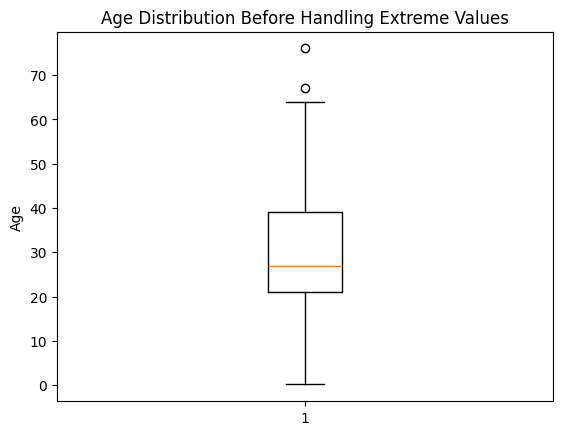

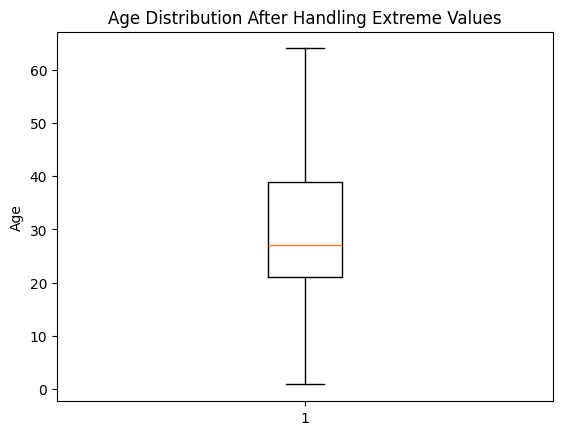

In [27]:
plt.boxplot(df['Age'].dropna())
plt.title("Age Distribution Before Handling Extreme Values")
plt.ylabel("Age")
plt.show()

df_cap = df.copy()                
df_cap['Age'] = df_cap['Age'].clip(lower, upper)  
lower = ages.quantile(0.01)
upper = ages.quantile(0.99)


plt.boxplot(df_cap['Age'].dropna())
plt.title("Age Distribution After Handling Extreme Values")
plt.ylabel("Age")
plt.show()




,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
count,1176.00,1176.00,1176.00,1176.00,1176.0,1176.00,1176.00,1176.00,1176.00,1176.00,...,1176.00,1176.00,1176.00,1176.00,1176.00,1176.00,1176.00,1176.00,1176.00,1176.00
mean,-0.00,-0.00,0.00,-0.00,0.0,0.00,0.00,-0.00,-0.00,0.00,...,-0.00,-0.00,0.00,0.00,-0.00,0.00,-0.00,-0.00,0.00,-0.00
std,1.00,1.00,1.00,1.00,0.0,1.00,1.00,1.00,1.00,1.00,...,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-2.04,-1.72,-1.01,-1.83,0.0,-1.69,-1.56,-1.79,-2.41,-0.93,...,-0.46,-0.27,-0.32,-0.25,-0.51,-0.52,-0.26,-0.94,-0.66,-0.64
25%,-0.74,-0.83,-0.89,-0.86,0.0,-0.88,-0.64,-0.91,-1.01,-0.93,...,-0.46,-0.27,-0.32,-0.25,-0.51,-0.52,-0.26,-0.94,-0.66,-0.64
50%,-0.08,-0.01,-0.28,0.10,0.0,-0.02,0.28,0.02,0.39,-0.03,...,-0.46,-0.27,-0.32,-0.25,-0.51,-0.52,-0.26,-0.94,-0.66,-0.64
75%,0.68,0.88,0.58,1.06,0.0,0.89,1.20,0.85,0.39,0.88,...,-0.46,-0.27,-0.32,-0.25,-0.51,-0.52,-0.26,1.07,1.51,1.57
max,2.52,1.72,2.42,2.03,0.0,1.71,1.20,1.63,1.79,2.70,...,2.18,3.73,3.16,4.04,1.96,1.91,3.83,1.07,1.51,1.57
